In [90]:
import seaborn as sns
import polars as pl
import matplotlib.pyplot as plt

PLOT_DIR = "../docs/presentation/images/plots/"
DATA_DIR = "./data/"

In [91]:
sns.set_theme(style="whitegrid", palette="Spectral")
sns.set_context("poster")

#### Utils

In [92]:
def splitting(df: pl.DataFrame, col:str, type: str, grid: int, init: str):
    return df.select("step", col).with_columns(
        pl.lit(type).alias("type"), 
        pl.lit(grid).alias("grid"),
        pl.lit(init).alias("init"),
        pl.lit(col).alias("id")
    ).rename({col: "value"})

def renaming(df: pl.DataFrame, suffix: str, prefix: str):
    mapping = { 
        "shape_net": 
        {
            f"08-02_18-31-55_ShapeNet_NeMo_Rec_local - {suffix}": "DMTet_16_Sphere",
            f"08-02_17-19-48_ShapeNet_NeMo_Rec_local - {suffix}": "FlexiCubes_32_Random",
            f"08-02_16-08-21_ShapeNet_NeMo_Rec_local - {suffix}": "FlexiCubes_16_Random",
            f"08-01_16-48-36_ShapeNet_NeMo_Rec_local - {suffix}": "DMTet_32_Random",
            f"08-01_16-23-41_ShapeNet_NeMo_Rec_local - {suffix}": "DMTet_32_Sphere",
            f"08-01_15-07-07_ShapeNet_NeMo_Rec_local - {suffix}": "FlexiCubes_32_Sphere",
            f"08-01_14-45-02_ShapeNet_NeMo_Rec_local - {suffix}": "DMTet_16_Random",
            f"08-01_13-40-44_ShapeNet_NeMo_Rec_local - {suffix}": "FlexiCubes_16_Sphere",
            "Step": "step"
        },
        "co3d": 
        {
            f"08-04_12-10-50_CO3D_NeMo_Rec_local - {suffix}": "DMTet_32_Random",
            f"08-04_11-24-50_CO3D_NeMo_Rec_local - {suffix}": "DMTet_32_Sphere",
            f"08-04_10-53-57_CO3D_NeMo_Rec_local - {suffix}": "FlexiCubes_32_Random",
            f"08-03_23-34-45_CO3D_NeMo_Rec_local - {suffix}": "FlexiCubes_16_Random",
            f"08-04_12-41-29_CO3D_NeMo_Rec_local - {suffix}": "FlexiCubes_32_Sphere",
            f"08-04_14-02-10_CO3D_NeMo_Rec_local - {suffix}": "DMTet_16_Sphere",
            f"08-04_15-17-40_CO3D_NeMo_Rec_local - {suffix}": "FlexiCubes_16_Sphere",
            "Step": "step"
        }
    }
    df = df.rename(mapping=mapping[prefix])

    if prefix == "co3d":
        cols = [
            "step",
            "DMTet_16_Sphere",
            "FlexiCubes_32_Random",
            "FlexiCubes_16_Random",
            "DMTet_32_Random",
            "DMTet_32_Sphere",
            "FlexiCubes_32_Sphere",
            "FlexiCubes_16_Sphere",
        ]
    elif prefix == "shape_net":
        cols = [
            "step",
            "DMTet_16_Sphere",
            "FlexiCubes_32_Random",
            "FlexiCubes_16_Random",
            "DMTet_32_Random",
            "DMTet_32_Sphere",
            "FlexiCubes_32_Sphere",
            "DMTet_16_Random",
            "FlexiCubes_16_Sphere",
        ]

    map = {
        i : {
            k[0]: k[1]
            for k in zip(["type", "grid", "init"], i.split("_"))
        }
        for i in cols[1:]
    }
    

    df = df.select(*cols)

    dfs = []
    for col in cols[1:]:
        vals = map[col]
        dfs.append(splitting(df, col, vals["type"], int(vals["grid"]), vals["init"]))

    df = pl.concat(dfs)
    return df

## ShapeNet 

In [93]:
shape_net_train_loss = pl.read_csv(DATA_DIR + "shape_net_train_loss" + ".csv")
shape_net_val_iou = pl.read_csv(DATA_DIR + "shape_net_val_iou" + ".csv")
shape_net_val_loss = pl.read_csv(DATA_DIR + "shape_net_val_loss" + ".csv")
shape_net_val_psnr = pl.read_csv(DATA_DIR + "shape_net_val_psnr" + ".csv")
shape_net_val_rec_mask_mse = pl.read_csv(DATA_DIR + "shape_net_val_rec_mask_mse" + ".csv")
shape_net_val_rec_rgb_mse = pl.read_csv(DATA_DIR + "shape_net_val_rec_rgb_mse" + ".csv")
shape_net_test_iou = pl.read_csv(DATA_DIR + "shape_net_test_iou" + ".csv")
shape_net_test_psnr = pl.read_csv(DATA_DIR + "shape_net_test_psnr" + ".csv")



In [94]:
shape_net_train_loss = renaming(shape_net_train_loss, "train/loss", "shape_net")
shape_net_val_iou = renaming(shape_net_val_iou, "val/shapenet/iou", "shape_net")
shape_net_val_loss = renaming(shape_net_val_loss, "val/shapenet/loss", "shape_net")
shape_net_val_psnr = renaming(shape_net_val_psnr, "val/shapenet/psnr", "shape_net")
shape_net_val_rec_mask_mse = renaming(shape_net_val_rec_mask_mse, "val/shapenet/rec_mask_mse", "shape_net")
shape_net_val_rec_rgb_mse = renaming(shape_net_val_rec_rgb_mse, "val/shapenet/rec_rgb_mse", "shape_net")
shape_net_test_iou = renaming(shape_net_test_iou, "test/shapenet/iou", "shape_net")
shape_net_test_psnr = renaming(shape_net_test_psnr, "test/shapenet/psnr", "shape_net")

#### Plots

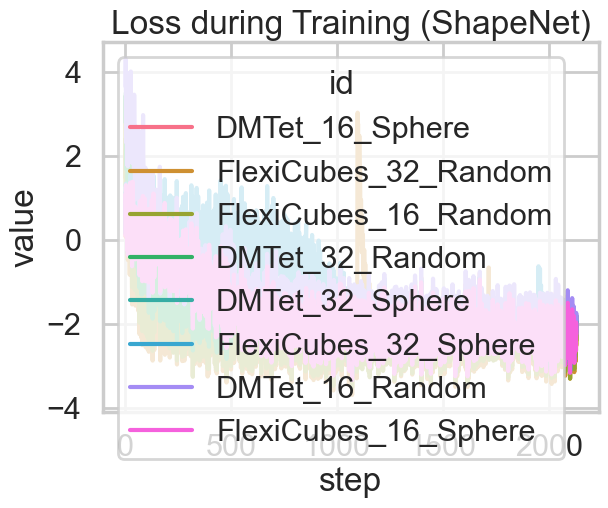

In [95]:
sns.lineplot(shape_net_train_loss, x="step", y="value", hue="id")
plt.title("Loss during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_train_loss" + ".svg", bbox_inches="tight")

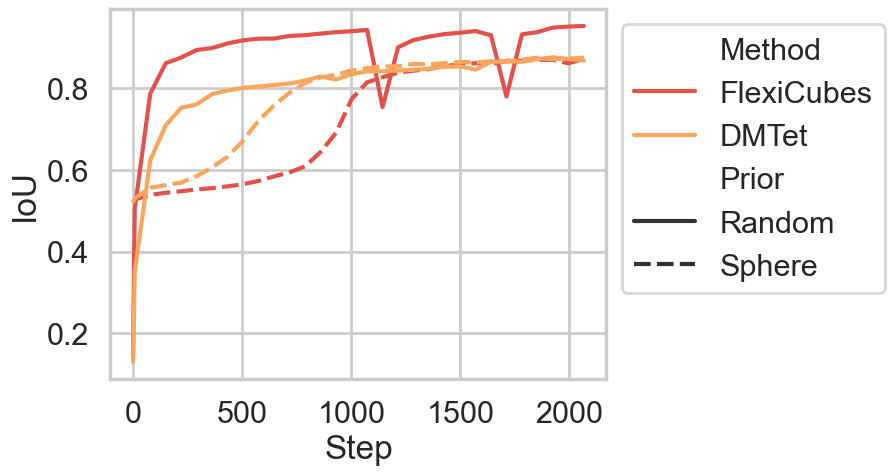

In [96]:
ax = sns.lineplot(shape_net_val_iou.rename({"value": "IoU", "type": "Method", "step": "Step", "init": "Prior"}).filter(pl.col("id").is_in(["DMTet_32_Sphere", "DMTet_32_Random", "FlexiCubes_32_Random", "FlexiCubes_32_Sphere"])), x="Step", y="IoU", hue="Method", style="Prior")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# plt.title("IOU on Validation Set during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_val_iou" + ".svg", bbox_inches="tight")

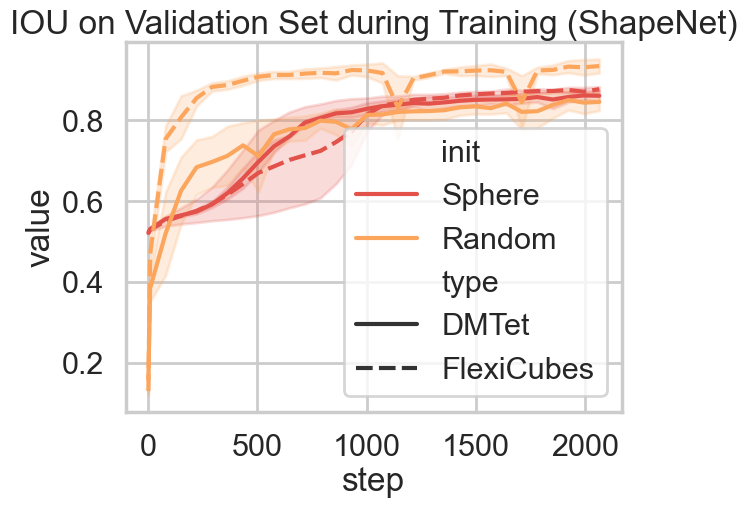

In [97]:
sns.lineplot(shape_net_val_iou, x="step", y="value", hue="init", style="type")
plt.title("IOU on Validation Set during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_val_iou_by_init_type" + ".svg", bbox_inches="tight")

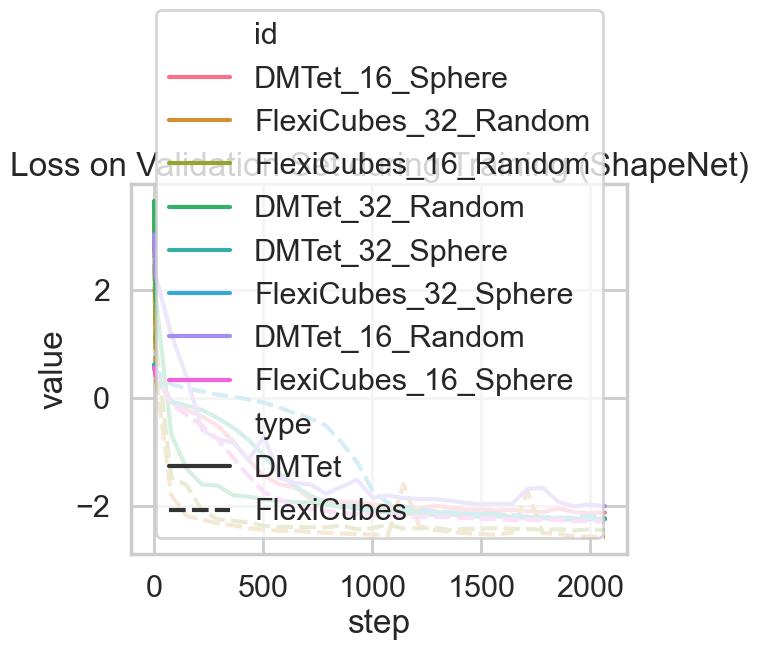

In [98]:
sns.lineplot(shape_net_val_loss, x="step", y="value", hue="id", style="type")
plt.title("Loss on Validation Set during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_val_loss" + ".svg", bbox_inches="tight")

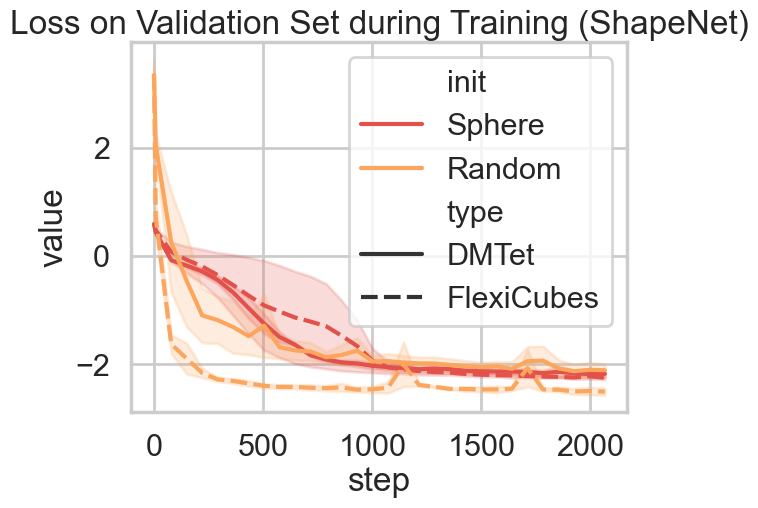

In [99]:
sns.lineplot(shape_net_val_loss, x="step", y="value", hue="init", style="type")
plt.title("Loss on Validation Set during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_val_loss_by_init_type" + ".svg", bbox_inches="tight")

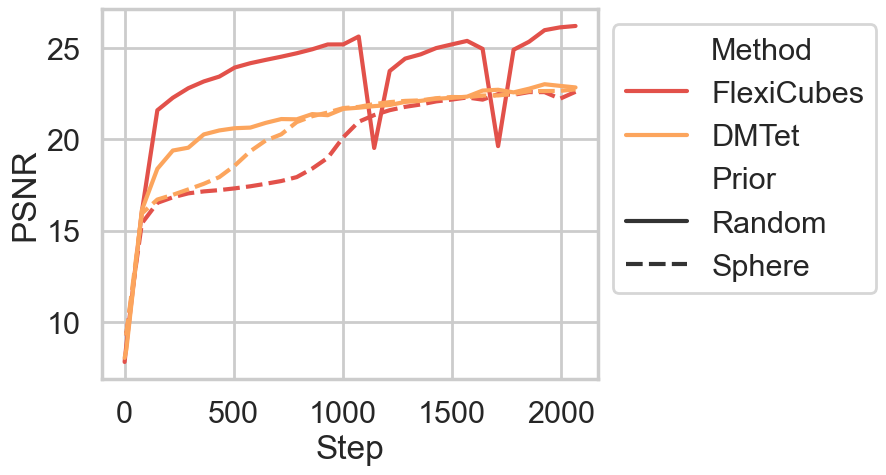

In [100]:
ax = sns.lineplot(shape_net_val_psnr.rename({"value": "PSNR", "type": "Method", "step": "Step", "init": "Prior"}).filter(pl.col("id").is_in(["DMTet_32_Sphere", "DMTet_32_Random", "FlexiCubes_32_Random", "FlexiCubes_32_Sphere"])), x="Step", y="PSNR", hue="Method", style="Prior")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# plt.title("PSNR on Validation Set during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_val_psnr" + ".svg", bbox_inches="tight")

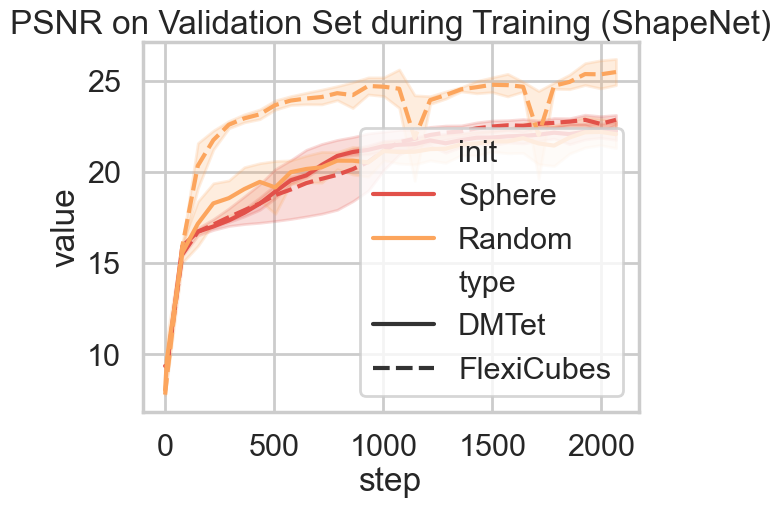

In [101]:
sns.lineplot(shape_net_val_psnr, x="step", y="value", hue="init", style="type")
plt.title("PSNR on Validation Set during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_val_psnr_by_init_type" + ".svg", bbox_inches="tight")

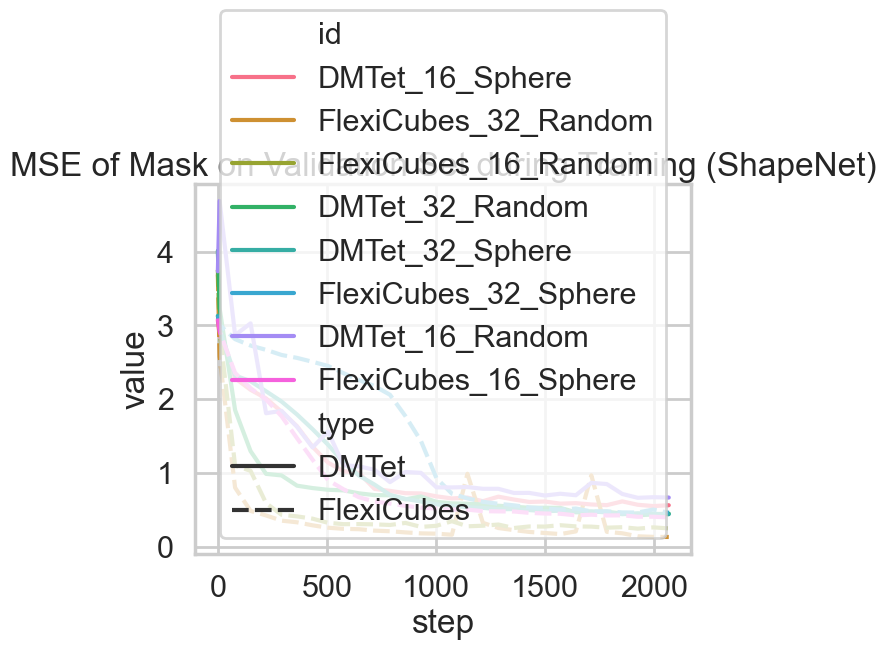

In [102]:
sns.lineplot(shape_net_val_rec_mask_mse, x="step", y="value", hue="id", style="type")
plt.title("MSE of Mask on Validation Set during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_val_rec_mask_mse" + ".svg", bbox_inches="tight")

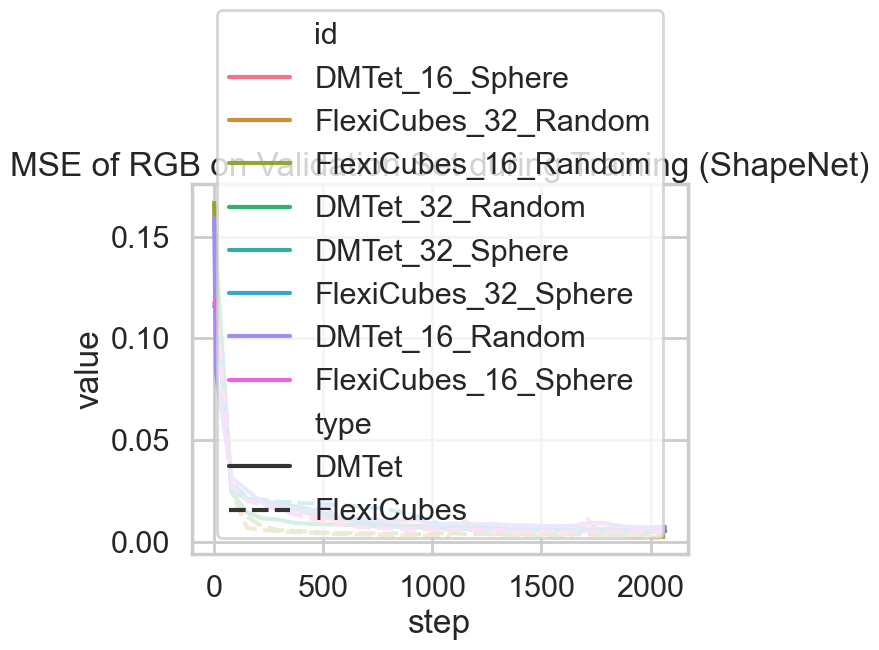

In [103]:
sns.lineplot(shape_net_val_rec_rgb_mse, x="step", y="value", hue="id", style="type")
plt.title("MSE of RGB on Validation Set during Training (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_val_rec_rgb_mse" + ".svg", bbox_inches="tight")

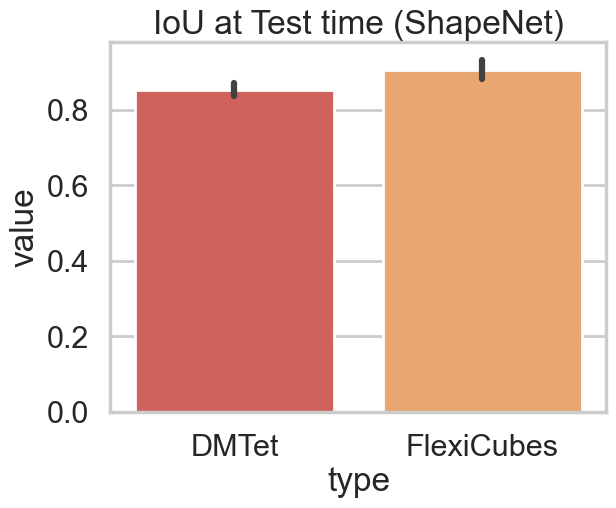

In [104]:
sns.barplot(shape_net_test_iou, x="type", y="value", hue="type")
plt.title("IoU at Test time (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_test_iou_by_type" + ".svg", bbox_inches="tight")

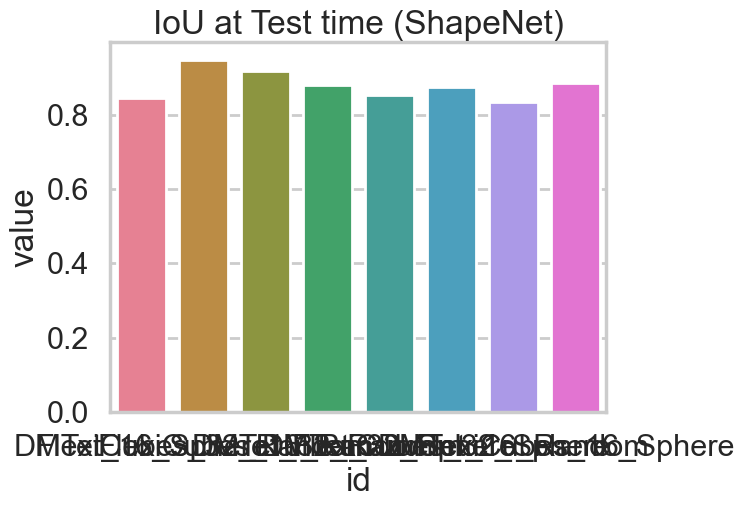

In [105]:
sns.barplot(shape_net_test_iou, x="id", y="value", hue="id")
plt.title("IoU at Test time (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_test_iou_by_id" + ".svg", bbox_inches="tight")

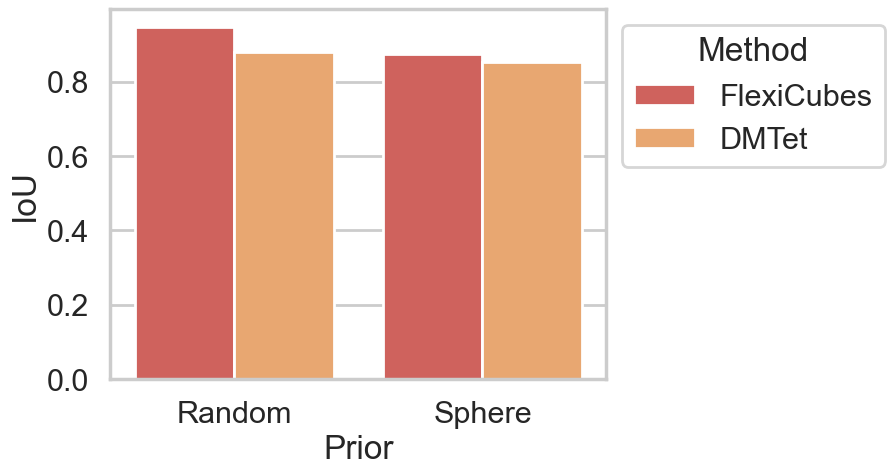

In [106]:
ax = sns.barplot(shape_net_test_iou.rename({"value": "IoU", "type": "Method", "step": "Step", "init": "Prior"}).filter(pl.col("grid") == 32), x="Prior", y="IoU", hue="Method")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# plt.title("IoU at Test time (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_test_iou_by_init_type" + ".svg", bbox_inches="tight")

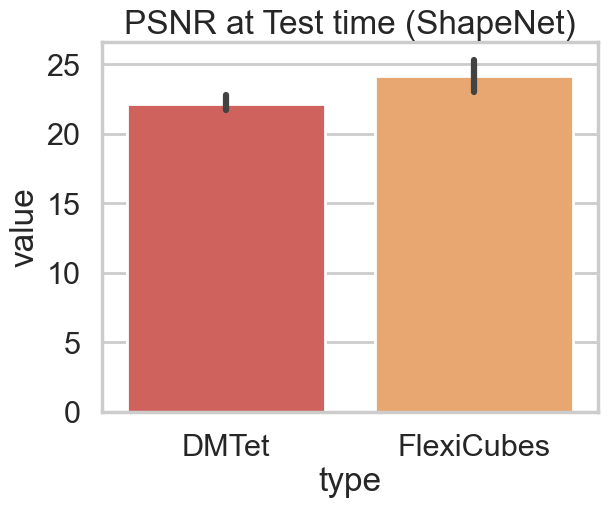

In [107]:
sns.barplot(shape_net_test_psnr, x="type", y="value", hue="type")
plt.title("PSNR at Test time (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_test_psnr_by_type" + ".svg", bbox_inches="tight")

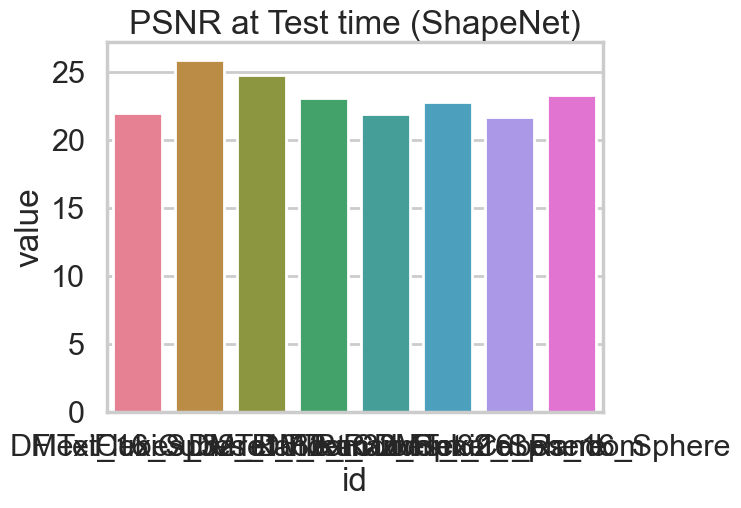

In [108]:
sns.barplot(shape_net_test_psnr, x="id", y="value", hue="id")
plt.title("PSNR at Test time (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_test_psnr_by_id" + ".svg", bbox_inches="tight")

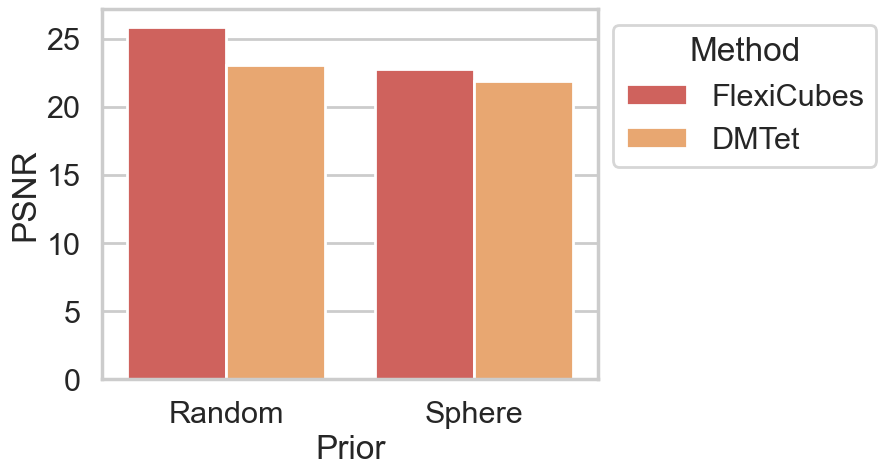

In [109]:
ax = sns.barplot(shape_net_test_psnr.rename({"value": "PSNR", "type": "Method", "step": "Step", "init": "Prior"}).filter(pl.col("grid") == 32), x="Prior", y="PSNR", hue="Method")
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# plt.title("PSNR at Test time (ShapeNet)")
plt.savefig(PLOT_DIR + "shape_net_test_psnr_by_init_type" + ".svg", bbox_inches="tight")

## CO3D

In [110]:
co3d_train_loss = pl.read_csv(DATA_DIR + "co3d_train_loss" + ".csv")
co3d_val_iou = pl.read_csv(DATA_DIR + "co3d_val_iou" + ".csv")
co3d_val_loss = pl.read_csv(DATA_DIR + "co3d_val_loss" + ".csv")
co3d_val_psnr = pl.read_csv(DATA_DIR + "co3d_val_psnr" + ".csv")
co3d_val_rec_mask_mse = pl.read_csv(DATA_DIR + "co3d_val_rec_mask_mse" + ".csv")
co3d_val_rec_rgb_mse = pl.read_csv(DATA_DIR + "co3d_val_rec_rgb_mse" + ".csv")
co3d_test_iou = pl.read_csv(DATA_DIR + "co3d_test_iou" + ".csv")
co3d_test_psnr = pl.read_csv(DATA_DIR + "co3d_test_psnr" + ".csv")

In [111]:
co3d_train_loss = renaming(co3d_train_loss, "train/loss", "co3d")
co3d_val_iou = renaming(co3d_val_iou, "val/co3d_no_zsp_1s_labeled_ref/iou", "co3d")
co3d_val_loss = renaming(co3d_val_loss, "val/co3d_no_zsp_1s_labeled_ref/loss", "co3d")
co3d_val_psnr = renaming(co3d_val_psnr, "val/co3d_no_zsp_1s_labeled_ref/psnr", "co3d")
co3d_val_rec_mask_mse = renaming(co3d_val_rec_mask_mse, "val/co3d_no_zsp_1s_labeled_ref/rec_mask_mse", "co3d")
co3d_val_rec_rgb_mse = renaming(co3d_val_rec_rgb_mse, "val/co3d_no_zsp_1s_labeled_ref/rec_rgb_mse", "co3d")
co3d_test_iou = renaming(co3d_test_iou, "test/co3d_no_zsp_1s_labeled_ref/iou", "co3d")
co3d_test_psnr = renaming(co3d_test_psnr, "test/co3d_no_zsp_1s_labeled_ref/psnr", "co3d")

#### Plots

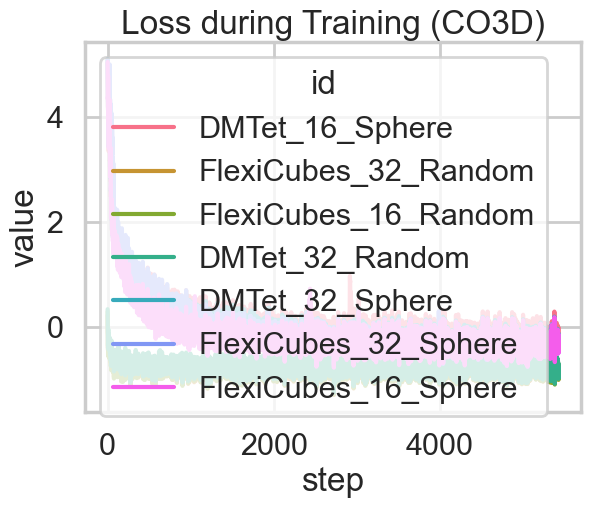

In [112]:
sns.lineplot(co3d_train_loss, x="step", y="value", hue="id")
plt.title("Loss during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_train_loss" + ".svg", bbox_inches="tight")

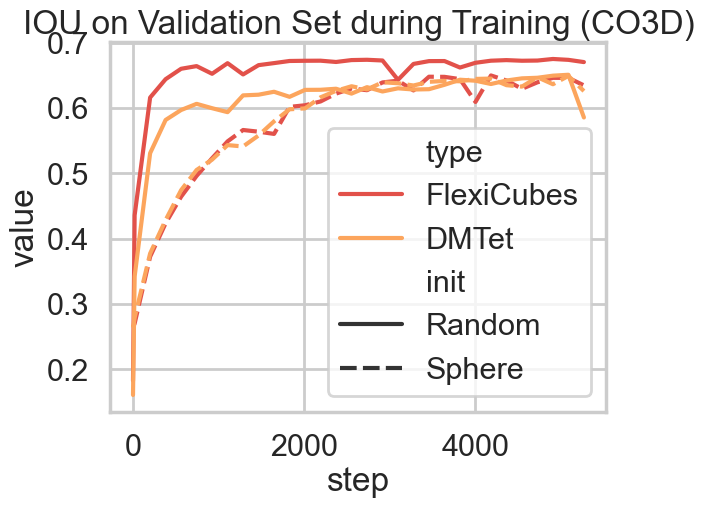

In [113]:
sns.lineplot(co3d_val_iou.filter(pl.col("id").is_in(["DMTet_32_Sphere", "DMTet_32_Random", "FlexiCubes_32_Random", "FlexiCubes_32_Sphere"])), x="step", y="value", hue="type", style="init")
plt.title("IOU on Validation Set during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_val_iou" + ".svg", bbox_inches="tight")

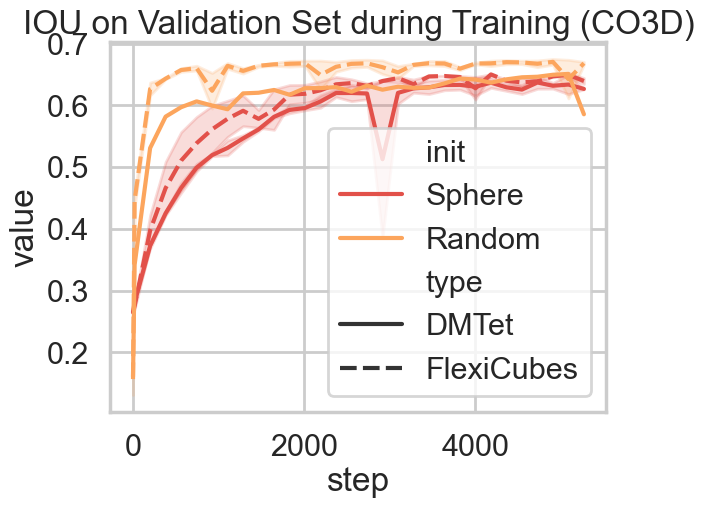

In [114]:
sns.lineplot(co3d_val_iou, x="step", y="value", hue="init", style="type")
plt.title("IOU on Validation Set during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_val_iou_by_init_type" + ".svg", bbox_inches="tight")

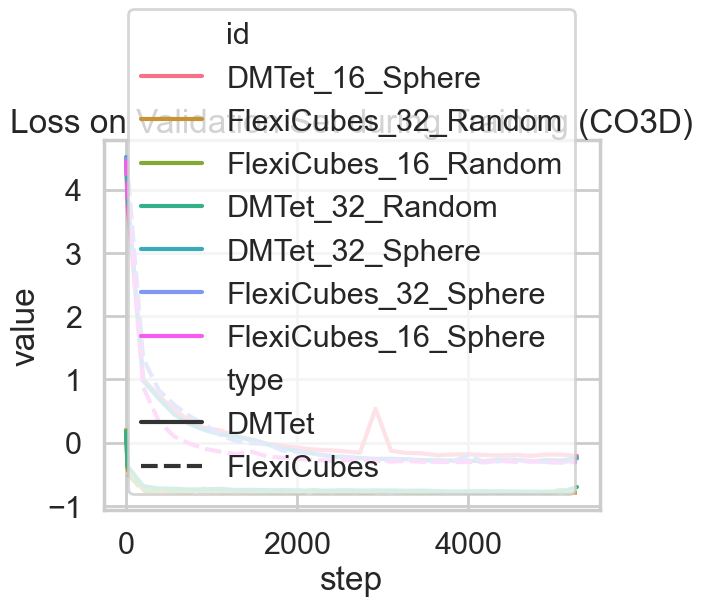

In [115]:
sns.lineplot(co3d_val_loss, x="step", y="value", hue="id", style="type")
plt.title("Loss on Validation Set during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_val_loss" + ".svg", bbox_inches="tight")

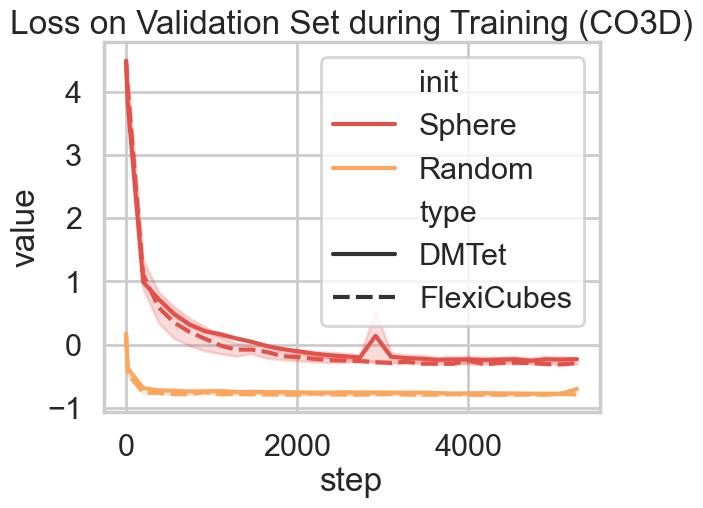

In [116]:
sns.lineplot(co3d_val_loss, x="step", y="value", hue="init", style="type")
plt.title("Loss on Validation Set during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_val_loss_by_init_type" + ".svg", bbox_inches="tight")

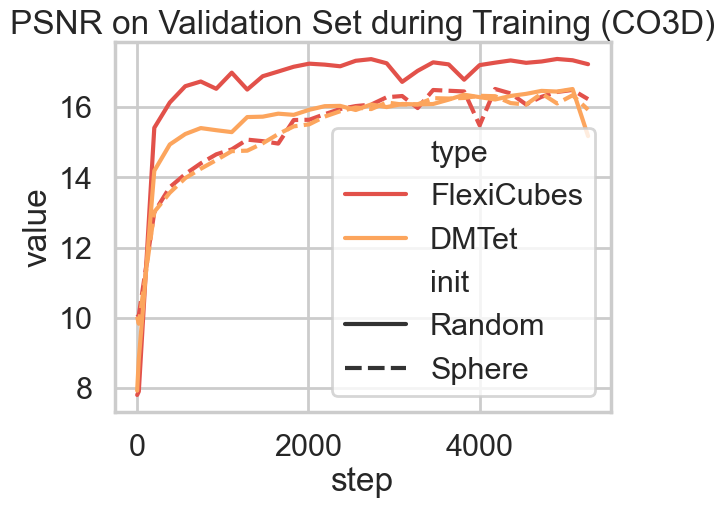

In [117]:
sns.lineplot(co3d_val_psnr.filter(pl.col("id").is_in(["DMTet_32_Sphere", "DMTet_32_Random", "FlexiCubes_32_Random", "FlexiCubes_32_Sphere"])), x="step", y="value", hue="type", style="init")
plt.title("PSNR on Validation Set during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_val_psnr" + ".svg", bbox_inches="tight")

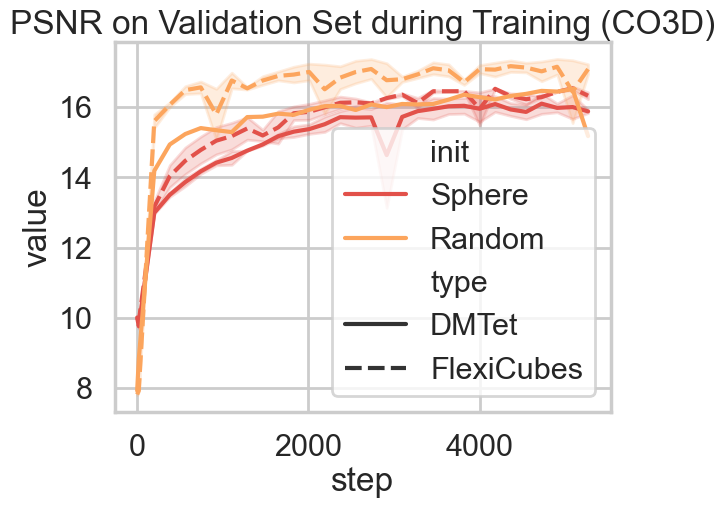

In [118]:
sns.lineplot(co3d_val_psnr, x="step", y="value", hue="init", style="type")
plt.title("PSNR on Validation Set during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_val_psnr_by_init_type" + ".svg", bbox_inches="tight")

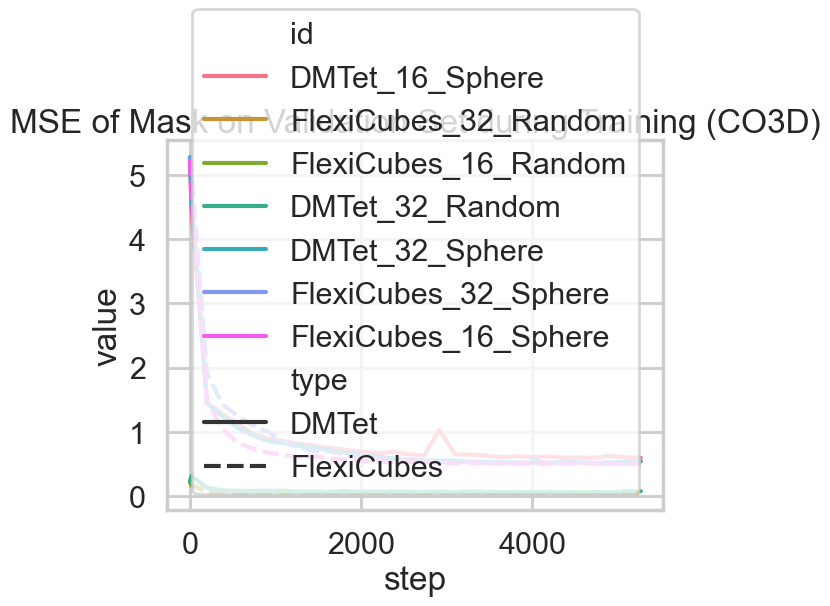

In [119]:
sns.lineplot(co3d_val_rec_mask_mse, x="step", y="value", hue="id", style="type")
plt.title("MSE of Mask on Validation Set during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_val_rec_mask_mse" + ".svg", bbox_inches="tight")

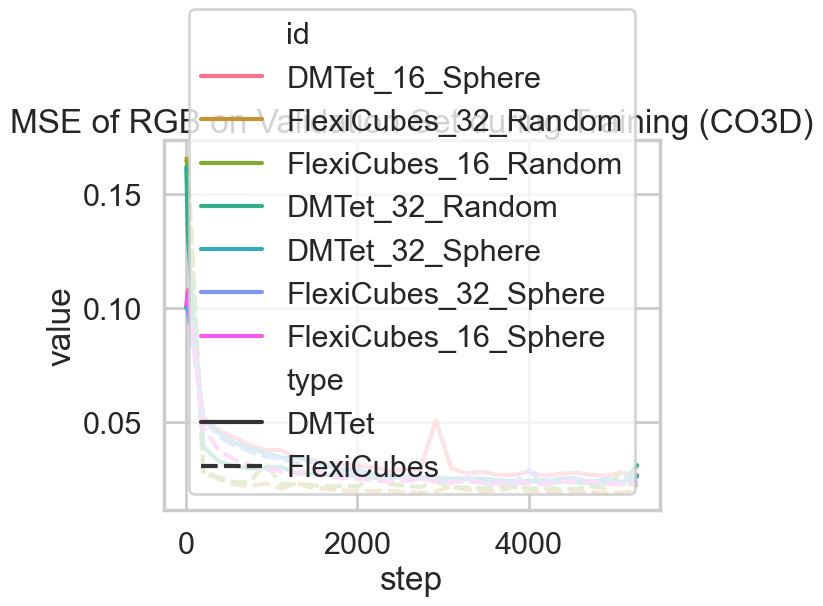

In [120]:
sns.lineplot(co3d_val_rec_rgb_mse, x="step", y="value", hue="id", style="type")
plt.title("MSE of RGB on Validation Set during Training (CO3D)")
plt.savefig(PLOT_DIR + "co3d_val_rec_rgb_mse" + ".svg", bbox_inches="tight")

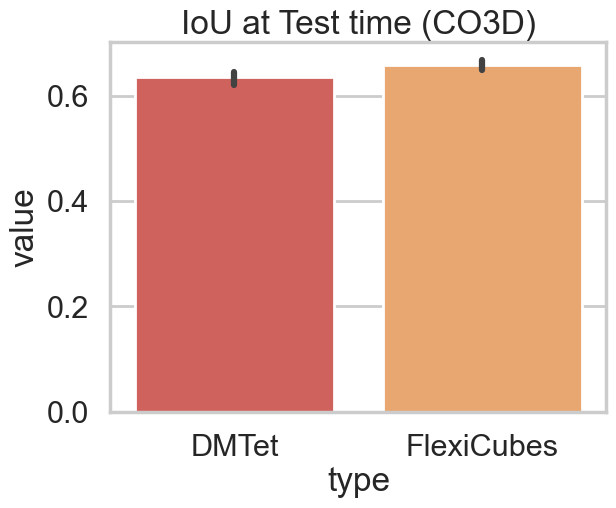

In [121]:
sns.barplot(co3d_test_iou, x="type", y="value", hue="type")
plt.title("IoU at Test time (CO3D)")
plt.savefig(PLOT_DIR + "co3d_test_iou_by_type" + ".svg", bbox_inches="tight")

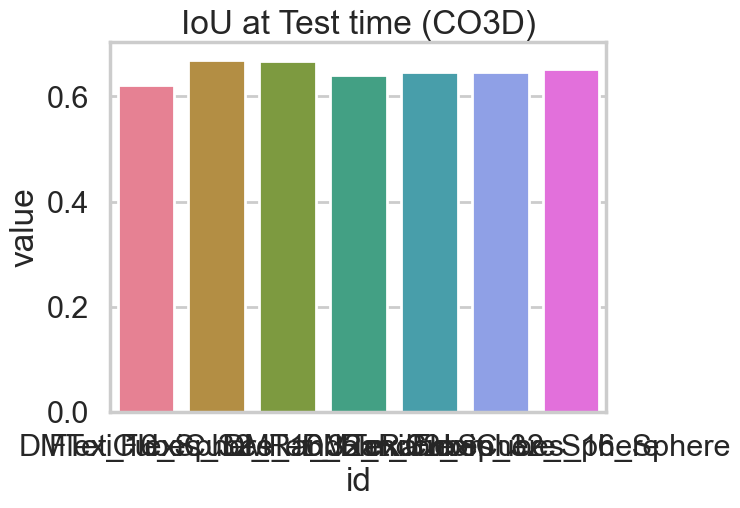

In [122]:
sns.barplot(co3d_test_iou, x="id", y="value", hue="id")
plt.title("IoU at Test time (CO3D)")
plt.savefig(PLOT_DIR + "co3d_test_iou_by_id" + ".svg", bbox_inches="tight")

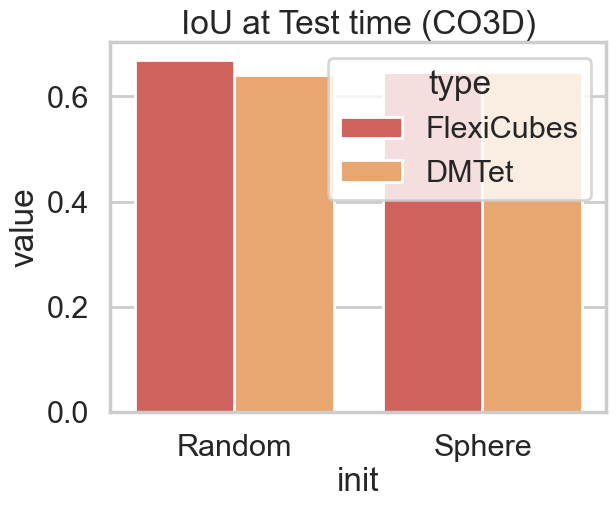

In [123]:
sns.barplot(co3d_test_iou.filter(pl.col("grid") == 32), x="init", y="value", hue="type")
plt.title("IoU at Test time (CO3D)")
plt.savefig(PLOT_DIR + "co3d_test_iou_by_init_type" + ".svg", bbox_inches="tight")

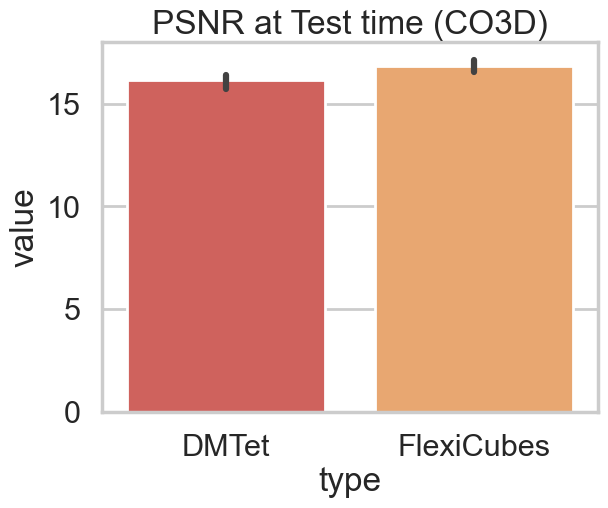

In [124]:
sns.barplot(co3d_test_psnr, x="type", y="value", hue="type")
plt.title("PSNR at Test time (CO3D)")
plt.savefig(PLOT_DIR + "co3d_test_psnr_by_type" + ".svg", bbox_inches="tight")

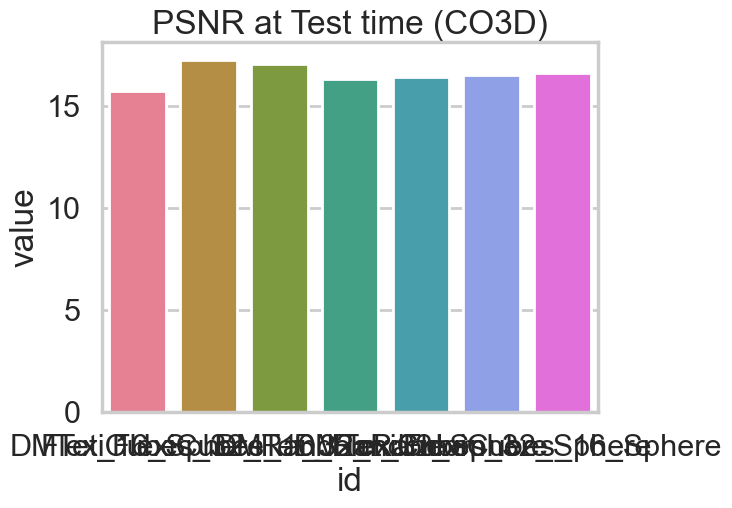

In [125]:
sns.barplot(co3d_test_psnr, x="id", y="value", hue="id")
plt.title("PSNR at Test time (CO3D)")
plt.savefig(PLOT_DIR + "co3d_test_psnr_by_id" + ".svg", bbox_inches="tight")

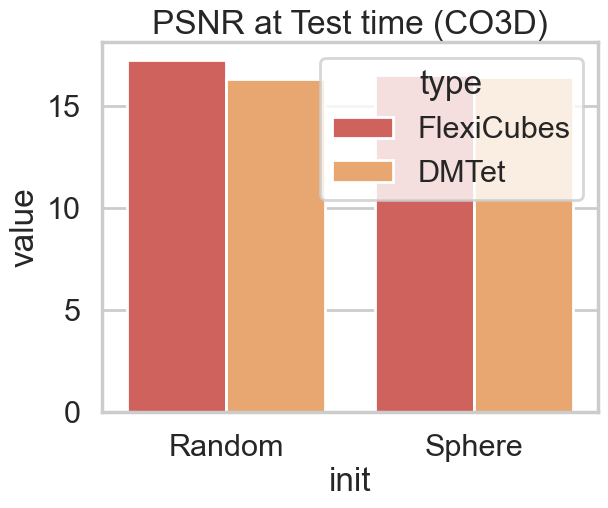

In [126]:
sns.barplot(co3d_test_psnr.filter(pl.col("grid") == 32), x="init", y="value", hue="type")
plt.title("PSNR at Test time (CO3D)")
plt.savefig(PLOT_DIR + "co3d_test_psnr_by_init_type" + ".svg", bbox_inches="tight")